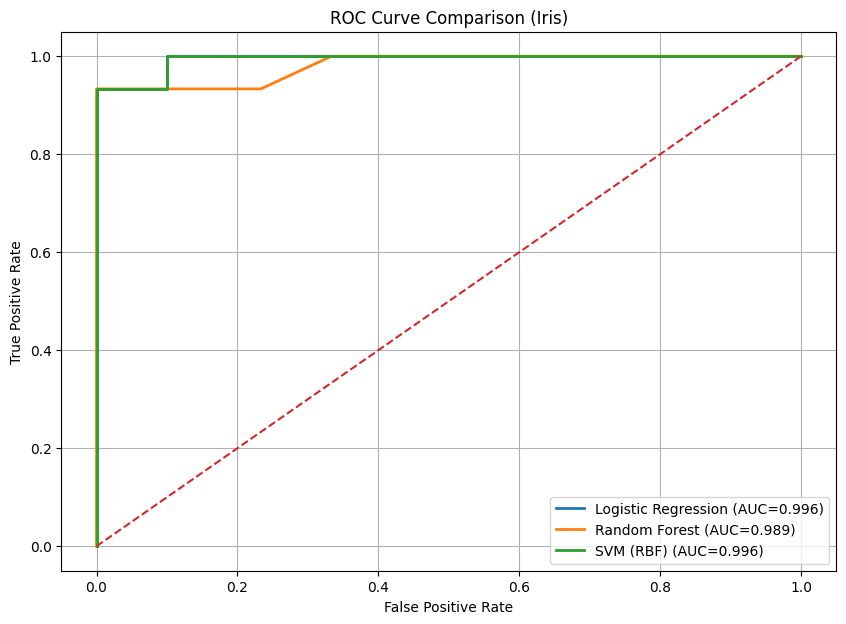


===== STRATIFIED 10-FOLD CROSS VALIDATION =====
Logistic Regression: Mean=0.9667 | Std=0.0333
Random Forest: Mean=0.9533 | Std=0.0521
SVM (RBF): Mean=0.9600 | Std=0.0442

===== METRICS SUMMARY =====

Logistic Regression
Accuracy : 0.9333
Precision: 0.9345
Recall   : 0.9333
F1-Score : 0.9333
AUC      : 0.9956

Random Forest
Accuracy : 0.8889
Precision: 0.8981
Recall   : 0.8889
F1-Score : 0.8878
AUC      : 0.9889

SVM (RBF)
Accuracy : 0.9556
Precision: 0.9556
Recall   : 0.9556
F1-Score : 0.9556
AUC      : 0.9956


In [2]:
# Task 7 Data Mining

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# =========================
# DATASET
# =========================
iris = load_iris()
X = iris.data
y = iris.target

# Binarize untuk ROC multi-class
y_bin = label_binarize(y, classes=[0, 1, 2])

# Split (y untuk training, y_bin untuk ROC)
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y, y_bin,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# =========================
# MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (RBF)": SVC(probability=True)
}

results = {}

# =========================
# TRAIN + EVALUATION + ROC
# =========================
plt.figure(figsize=(10, 7))

for name, model in models.items():
    # TRAIN pakai y (bukan one-hot)
    model.fit(X_train, y_train)

    # Probabilitas
    y_proba = model.predict_proba(X_test)

    # Prediksi kelas
    y_pred = model.predict(X_test)

    # ================= METRICS =================
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    # AUC multi-class
    auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')

    results[name] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc
    }

    # ROC (ambil class 1 sebagai contoh)
    fpr, tpr, _ = roc_curve(y_test_bin[:, 1], y_proba[:, 1])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

# Plot ROC
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Iris)")
plt.legend()
plt.grid()
plt.show()

# =========================
# STRATIFIED 10-FOLD CV
# =========================
print("\n===== STRATIFIED 10-FOLD CROSS VALIDATION =====")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"{name}: Mean={scores.mean():.4f} | Std={scores.std():.4f}")

# =========================
# METRICS SUMMARY
# =========================
print("\n===== METRICS SUMMARY =====")

for name, m in results.items():
    print(f"\n{name}")
    print(f"Accuracy : {m['accuracy']:.4f}")
    print(f"Precision: {m['precision']:.4f}")
    print(f"Recall   : {m['recall']:.4f}")
    print(f"F1-Score : {m['f1']:.4f}")
    print(f"AUC      : {m['auc']:.4f}")